**Problem Statement**

Use a classification model to infer what a winning team's profile looks like, and then test it on USA and Belgium's profile to gain insights on Monday's game: USA vs. Belgium. 


predictors = "possession", "goals_per90", "assists_per90",
                "shots_on_target_pct", "goals_per90_against",
                "tackles_won", "interceptions", "gk_save_pct",
                "cards_yellow", "cards_red", "fouls"
                
target variable = "Advanced" = games > 3. 

Our test data will be the Belgium & USA profile. 



**Loading, Inspecting, and EDA**

In [1]:
library(tidyverse)
library(tidymodels)
library(discrim)
library(DT)
library(patchwork)
library(yardstick)
library(probably)
library(data.table)
library(ggcorrplot)

── Attaching core tidyverse packages ─────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.5.2
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ───────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


Warning messages:
1: package ‘tidyverse’ was built under R version 4.5.3 
2: package ‘ggplot2’ was built under R version 4.5.3 
3: package ‘tibble’ was built under R version 4.5.2 
4: package ‘tidyr’ was built under R version 4.5.2 
5: package ‘readr’ was built under R version 4.5.3 
6: package ‘purrr’ was built under R version 4.5.3 
7: package ‘dplyr’ was built under R version 4.5.3 
8: package ‘forcats’ was built under R version 4.5.2 
9: package ‘lubridate’ was built under R version 4.5.3 


── Attaching packages ───────────────────────────────────────────────────────────────────────────── tidymodels 1.5.0 ──
✔ broom        1.0.13     ✔ rsample      1.3.2 
✔ dials        1.4.3      ✔ tailor       0.1.0 
✔ infer        1.1.0      ✔ tune         2.1.0 
✔ modeldata    1.5.1      ✔ workflows    1.3.0 
✔ parsnip      1.6.0      ✔ workflowsets 1.1.1 
✔ recipes      1.3.2      ✔ yardstick    1.4.0 
── Conflicts ──────────────────────────────────────────────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filter()   masks stats::filter()
✖ recipes::fixed()  masks stringr::fixed()
✖ dplyr::lag()      masks stats::lag()
✖ yardstick::spec() masks readr::spec()
✖ recipes::step()   masks stats::step()
• Dig deeper into tidy modeling with R at https://www.tmwr.org


There were 14 warnings (use warnings() to see them)



Attaching package: ‘discrim’

The following object is masked from ‘package:dials’:

    smoothness



Warning message:
package ‘discrim’ was built under R version 4.5.3 
Warning message:
package ‘DT’ was built under R version 4.5.3 
Warning message:
package ‘patchwork’ was built under R version 4.5.2 



Attaching package: ‘probably’

The following objects are masked from ‘package:base’:

    as.factor, as.ordered



Warning message:
package ‘probably’ was built under R version 4.5.3 


data.table 1.18.0 using 6 threads (see ?getDTthreads).  Latest news: r-datatable.com

Attaching package: ‘data.table’

The following objects are masked from ‘package:lubridate’:

    hour, isoweek, isoyear, mday, minute, month, quarter, second, wday, week, yday, year

The following objects are masked from ‘package:dplyr’:

    between, first, last

The following object is masked from ‘package:purrr’:

    transpose



Warning message:
package ‘data.table’ was built under R version 4.5.2 
Warning message:
package ‘ggcorrplot’ was built under R version 4.5.3 


In [2]:
setwd("C:/Users/karth/PersonalProjects/WorldCupClassification")

In [3]:
worldCupData <- readr::read_csv("teams.csv")

Rows: 48 Columns: 136
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr   (2): team, team_country
dbl (130): players_used, avg_age, possession, games, games_starts, minutes, minutes_90s, goals, assists, goals_assi...
lgl   (4): pens_won, pens_conceded, pens_won_against, pens_conceded_against

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
head(worldCupData)

# A tibble: 6 × 136
  team  team_country players_used avg_age possession games games_starts minutes minutes_90s goals assists goals_assists
  <chr> <chr>               <dbl>   <dbl>      <dbl> <dbl>        <dbl>   <dbl>       <dbl> <dbl>   <dbl>         <dbl>
1 Alge… Algeria                22    27.7       61       4           44     360         4       5       3             8
2 Arge… Argentina              24    29.7       58.3     3           33     270         3       8       3            11
3 Aust… Australia              20    25.6       40.7     3           33     270         3       2       1             3
4 Aust… Austria                20    29.2       45       4           44     360         4       5       4             9
5 Belg… Belgium                20    29.8       57.8     4           44     390         4.3     8       5            13
6 Bosn… Bosnia and …           23    27         46       4           44     360         4       4       3             7
# ℹ 124 more variabl

**Taking a look at the data, we can see a lot of null columns, null values, and columns we are not really interested in**

We are going to focus on a target column = Advanced

In [5]:
worldCupData |> glimpse()

Rows: 48
Columns: 136
$ team                               <chr> "Algeria", "Argentina", "Australia", "Austria", "Belgium", "Bosnia–Herz", …
$ team_country                       <chr> "Algeria", "Argentina", "Australia", "Austria", "Belgium", "Bosnia and Her…
$ players_used                       <dbl> 22, 24, 20, 20, 20, 23, 22, 21, 21, 20, 21, 19, 22, 21, 22, 21, 20, 20, 21…
$ avg_age                            <dbl> 27.7, 29.7, 25.6, 29.2, 29.8, 27.0, 29.6, 31.3, 27.4, 30.6, 29.2, 29.5, 29…
$ possession                         <dbl> 61.0, 58.3, 40.7, 45.0, 57.8, 46.0, 57.8, 37.3, 56.8, 60.3, 40.0, 49.8, 32…
$ games                              <dbl> 4, 3, 3, 4, 4, 4, 4, 3, 4, 3, 4, 4, 3, 3, 4, 4, 3, 4, 4, 4, 3, 3, 3, 3, 4,…
$ games_starts                       <dbl> 44, 33, 33, 44, 44, 44, 44, 33, 44, 33, 44, 44, 33, 33, 44, 44, 33, 44, 44…
$ minutes                            <dbl> 360, 270, 270, 360, 390, 360, 360, 270, 360, 270, 360, 360, 270, 270, 360,…
$ minutes_90s             

In [112]:
worldCupData <- worldCupData |>
  mutate(
    Advanced = factor(
      if_else(games > 3, "Advanced", "Eliminated"), 
      levels = c("Advanced", "Eliminated")
    )
  ) |>
    mutate(
    fouls_per90 = fouls / minutes_90s,
    tackles_won_per90 = tackles_won / minutes_90s,
    interceptions_per90 = interceptions / minutes_90s,
    cards_yellow_per90 = cards_yellow / minutes_90s,
    cards_red_per90 = cards_red / minutes_90s
  )
worldCupData |> count(Advanced)

# A tibble: 2 × 2
  Advanced       n
  <fct>      <int>
1 Advanced      26
2 Eliminated    22

In [114]:
predictors <- c("possession", "goals_per90", "assists_per90",
                "shots_on_target_pct", "goals_per90_against",
                "tackles_won_per90", "interceptions_per90", "gk_save_pct",
                "cards_yellow_per90", "cards_red_per90", "fouls_per90")

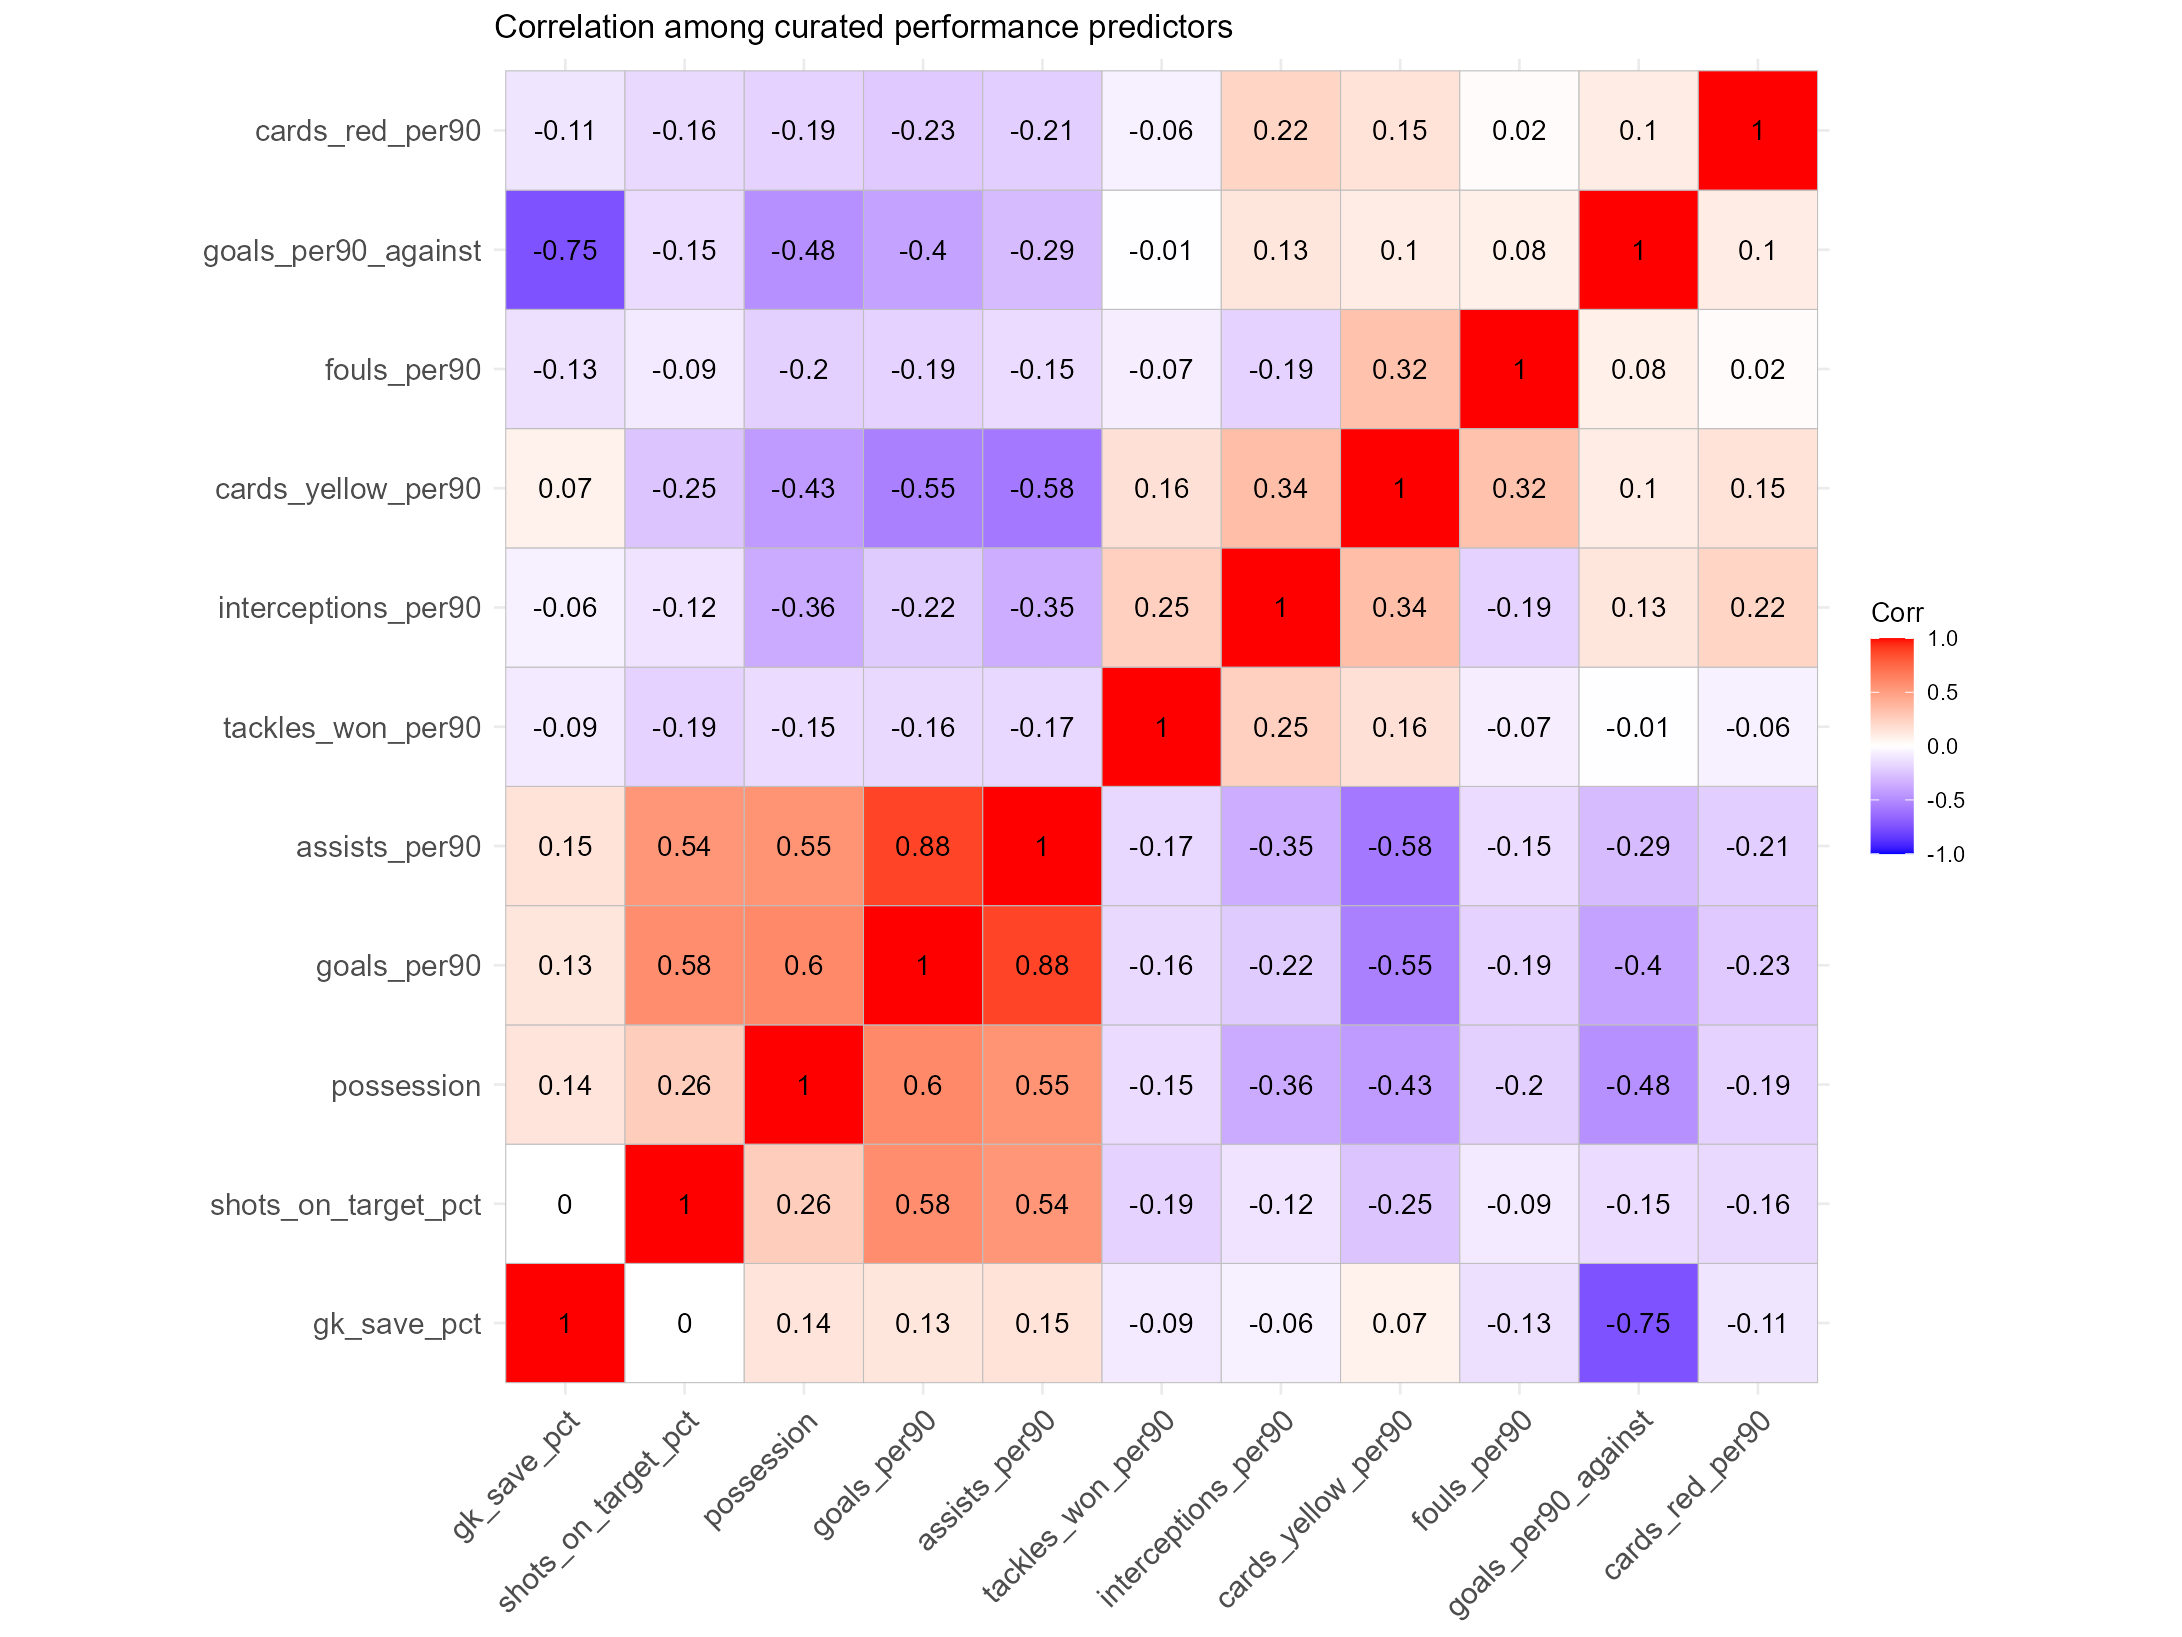

In [115]:
corr <- worldCupData |>
  select(all_of(predictors)) |>
  select(where(~ !anyNA(.))) |>
  cor()

ggcorrplot(corr, hc.order = TRUE, lab = TRUE,
           title = "Correlation among curated performance predictors")

In [122]:
train_set <- c("Advanced","possession", "goals_per90", "assists_per90",
                "shots_on_target_pct", "goals_per90_against",
                "tackles_won_per90", "interceptions_per90", "gk_save_pct",
                "cards_yellow_per90", "cards_red_per90", "fouls_per90")
train <- worldCupData |>
  filter(!team %in% c("Belgium", "United States")) |>
  select(team, all_of(train_set))

test <- worldCupData |>
  filter(team %in% c("Belgium", "United States")) |>
  select(team, all_of(predictors))

In [133]:
folds <- vfold_cv(train, v=5, strata=Advanced)
formula <- Advanced ~ possession + goals_per90 + assists_per90 + shots_on_target_pct +
  goals_per90_against + tackles_won_per90 + interceptions_per90 + gk_save_pct +
  cards_yellow_per90 + cards_red_per90 + fouls_per90

advance_recipe <- recipe(formula, data = train)|>
  step_normalize(all_numeric_predictors())
log_spec <- logistic_reg(penalty = tune(), mixture = 1) |>
  set_engine("glmnet")

log_wf <- workflow() |>
  add_model(log_spec) |>
  add_recipe(advance_recipe)

penalty_grid <- grid_regular(penalty(), levels = 20)

logreg_tune <- tune_grid(
  log_wf,
  resamples = folds,
  grid = penalty_grid,
  metrics = metric_set(roc_auc, accuracy)
)

lda_model <- discrim_linear() |>
  set_engine("MASS")
lda_wf <- workflow() |>
  add_model(lda_model) |>
  add_formula(formula)

best_penalty <- select_best(logreg_tune, metric = "roc_auc")
log_wf_final <- finalize_workflow(log_wf, best_penalty)

logreg_fit_cv <- log_wf_final |>
  fit_resamples(folds, control = control_resamples(save_pred = TRUE), metrics=metric_set(roc_auc, accuracy))

lda_fit_cv <- lda_wf |>
  fit_resamples(folds, control = control_resamples(save_pred = TRUE),
                metrics = metric_set(roc_auc, accuracy))

In [134]:
bind_rows(
  collect_metrics(logreg_fit_cv) |> mutate(model = "Elastic Net Logistic"),
  collect_metrics(lda_fit_cv) |> mutate(model = "LDA")
) |>
  select(model, .metric, mean, std_err) |>
  pivot_wider(names_from = .metric, values_from = c(mean, std_err)) |>
  knitr::kable(format="markdown")



|model                | mean_accuracy| mean_roc_auc| std_err_accuracy| std_err_roc_auc|
|:--------------------|-------------:|------------:|----------------:|---------------:|
|Elastic Net Logistic |     0.7294444|        0.791|        0.0718559|       0.0826499|
|LDA                  |     0.6400000|        0.650|        0.0889305|       0.1042113|

ROC_AUC CURVE

In [142]:
log_cv_roc <- collect_predictions(logreg_fit_cv) |>
  roc_curve(truth = Advanced, .pred_Advanced, event_level = "first")

lda_cv_roc <- collect_predictions(lda_fit_cv) |>
  roc_curve(truth = Advanced, .pred_Advanced, event_level = "first")

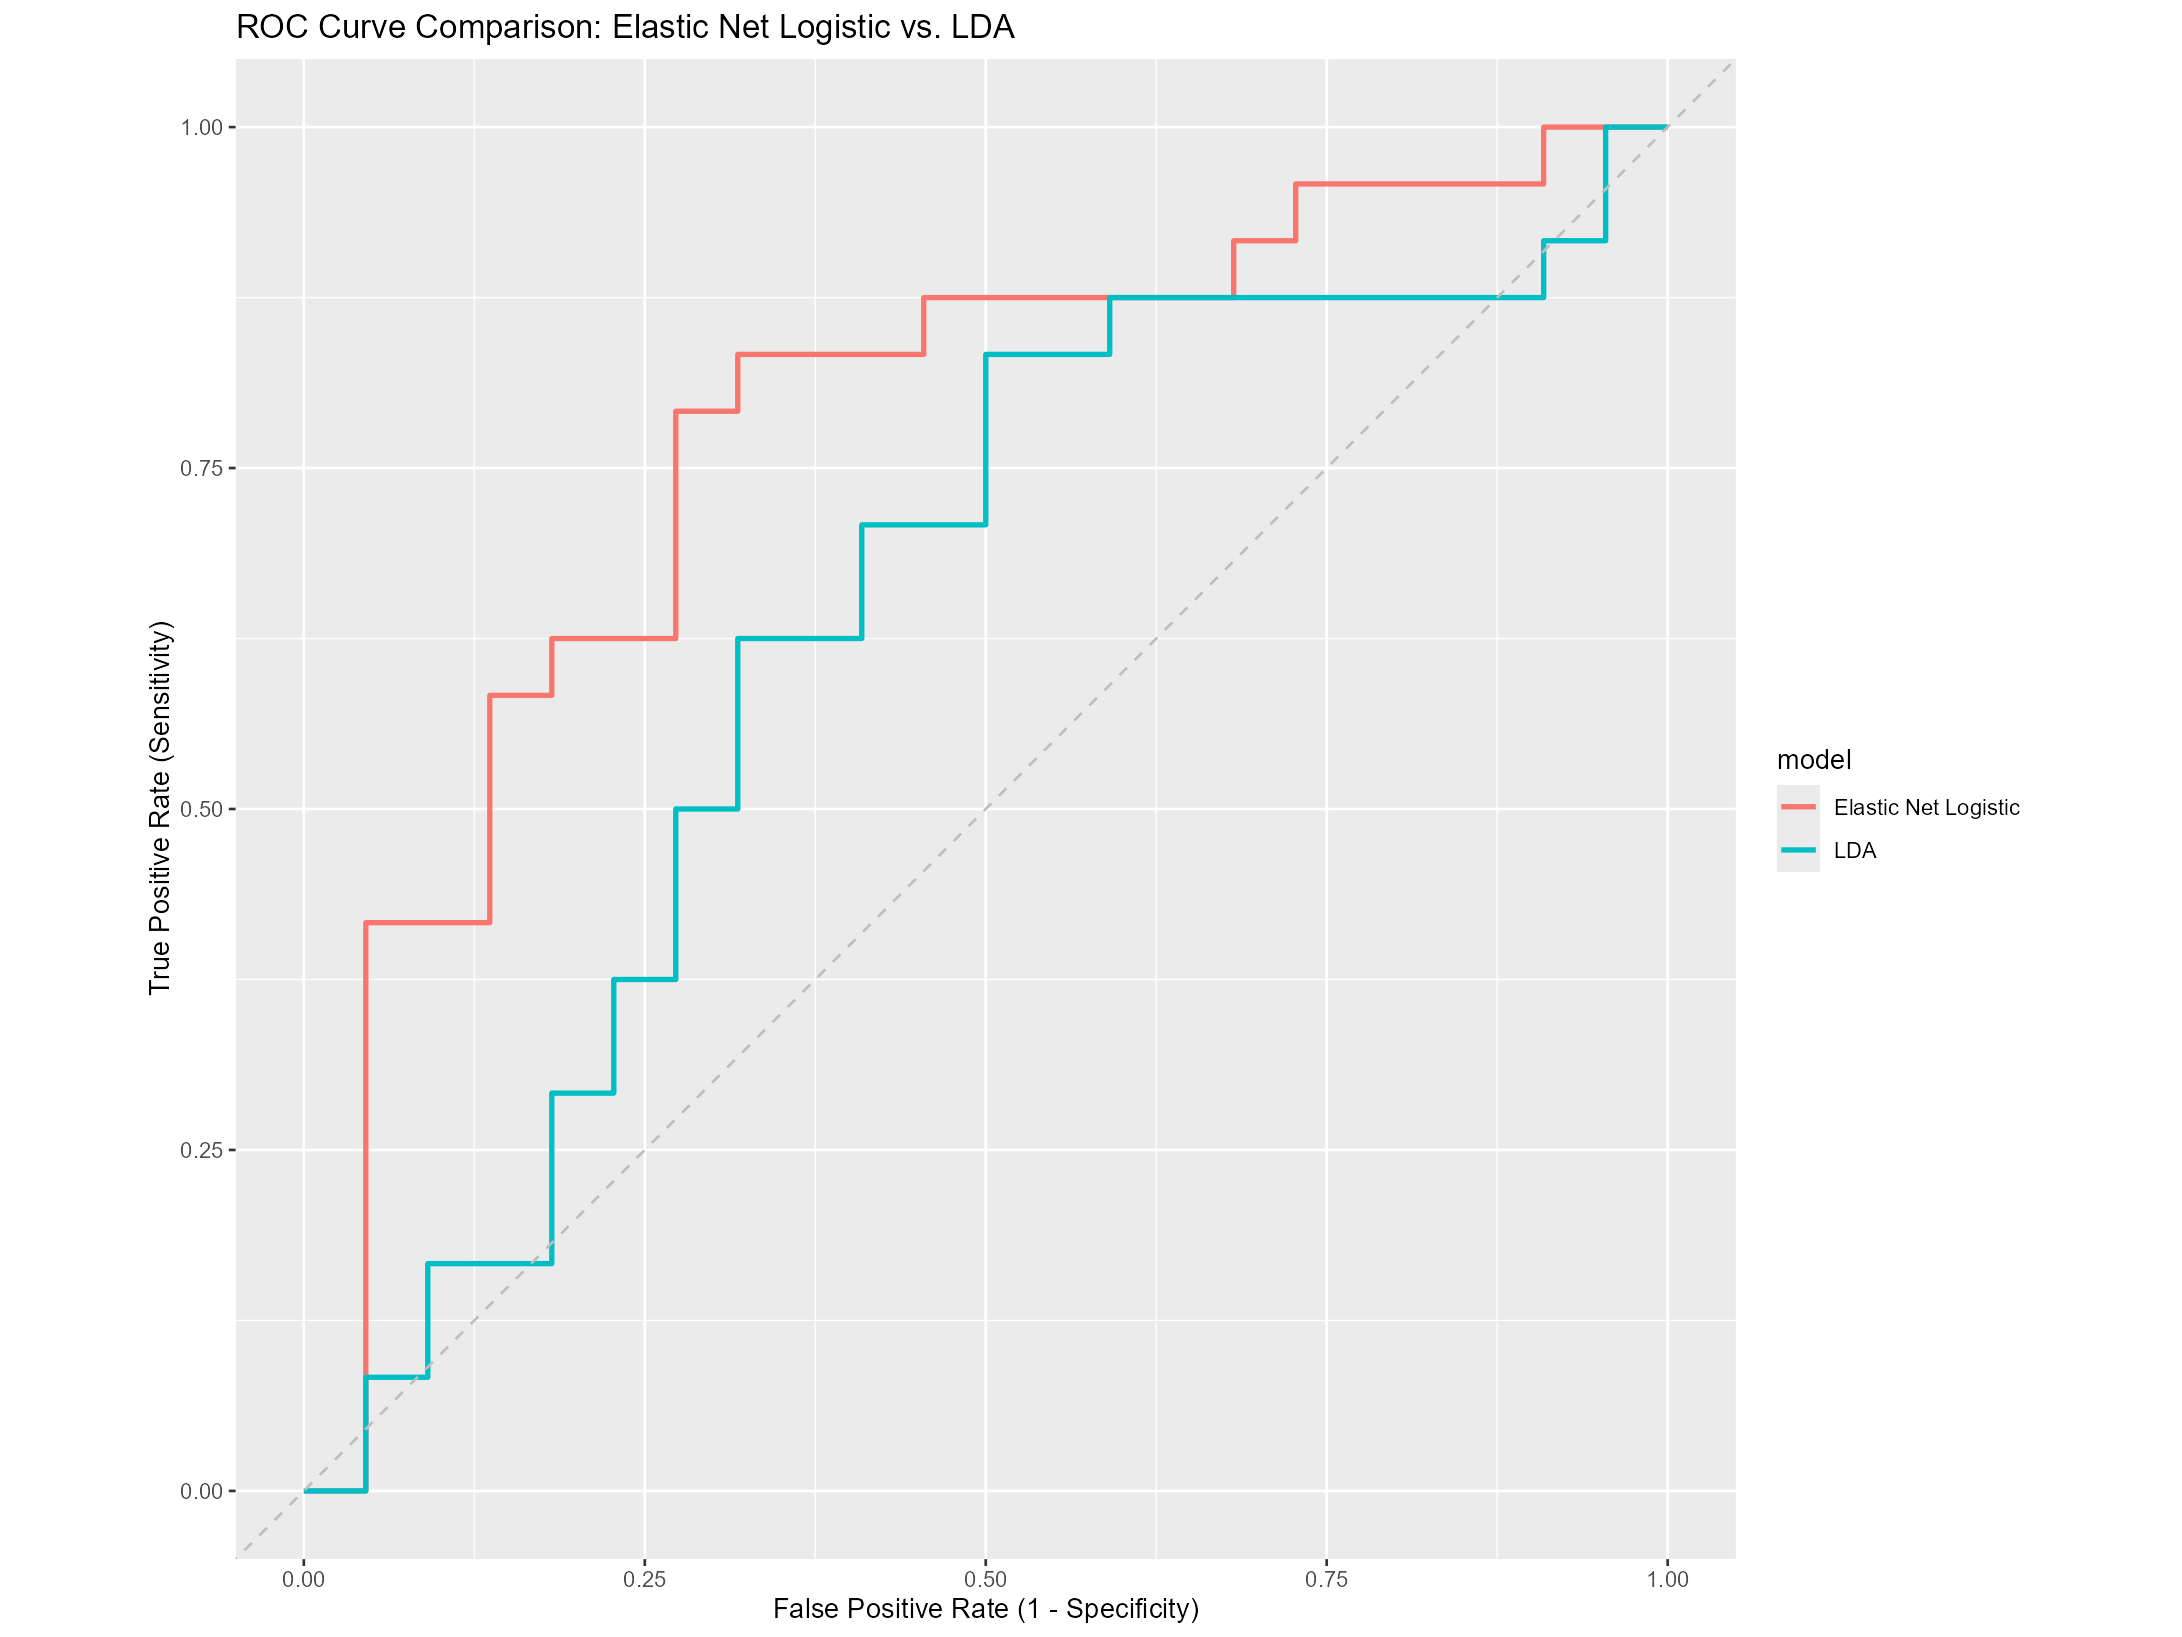

In [143]:
combined_roc <- bind_rows(
  log_cv_roc |> mutate(model = "Elastic Net Logistic"),
  lda_cv_roc |> mutate(model = "LDA")
)

combined_roc |>
  ggplot(aes(x = 1 - specificity, y = sensitivity, color = model)) +
  geom_path(linewidth = 1) +
  geom_abline(lty = 2, color = "gray") +
  coord_equal() +
  labs(title = "ROC Curve Comparison: Elastic Net Logistic vs. LDA",
       x = "False Positive Rate (1 - Specificity)",
       y = "True Positive Rate (Sensitivity)")

In [144]:
log_fit <- log_wf_final |> fit(data = train)
lda_fit <- lda_wf |> fit(data = train)

In [145]:
lda_test_preds <- augment(lda_fit, new_data = test)
log_test_preds <- augment(log_fit, new_data = test)

In [146]:
log_test_preds

# A tibble: 2 × 15
  .pred_class .pred_Advanced .pred_Eliminated team        possession goals_per90 assists_per90
  <fct>                <dbl>            <dbl> <chr>            <dbl>       <dbl>         <dbl>
1 Advanced             0.651            0.349 Belgium           57.8        1.85          1.15
2 Advanced             0.644            0.356 United Sta…       57          2             1   
# ℹ 8 more variables: shots_on_target_pct <dbl>, goals_per90_against <dbl>,
#   tackles_won_per90 <dbl>, interceptions_per90 <dbl>, gk_save_pct <dbl>,
#   cards_yellow_per90 <dbl>, cards_red_per90 <dbl>, fouls_per90 <dbl>

In [150]:

bind_rows(
  log_test_preds |> mutate(model = "Logistic Regression"),
  lda_test_preds |> mutate(model = "LDA")
) |>
  select(model, team, .pred_Advanced, .pred_Eliminated) |> 
  knitr::kable(format = "markdown")



|model               |team          | .pred_Advanced| .pred_Eliminated|
|:-------------------|:-------------|--------------:|----------------:|
|Logistic Regression |Belgium       |      0.6512436|        0.3487564|
|Logistic Regression |United States |      0.6441139|        0.3558861|
|LDA                 |Belgium       |      0.8780026|        0.1219974|
|LDA                 |United States |      0.6702437|        0.3297563|

In [151]:
log_fit |>
  tidy()

# A tibble: 12 × 3
   term                estimate penalty
   <chr>                  <dbl>   <dbl>
 1 (Intercept)           -0.140  0.0886
 2 possession             0      0.0886
 3 goals_per90           -0.474  0.0886
 4 assists_per90         -0.593  0.0886
 5 shots_on_target_pct    0      0.0886
 6 goals_per90_against    0      0.0886
 7 tackles_won_per90      0      0.0886
 8 interceptions_per90    0      0.0886
 9 gk_save_pct            0      0.0886
10 cards_yellow_per90     0      0.0886
11 cards_red_per90        0      0.0886
12 fouls_per90            0      0.0886

In [152]:
coefs <- tidy(extract_fit_parsnip(log_fit)) |>
  mutate(estimate = -estimate) |>
  arrange(desc(abs(estimate))) |>
  knitr::kable("markdown")

coefs



|term                |  estimate|   penalty|
|:-------------------|---------:|---------:|
|assists_per90       | 0.5931575| 0.0885867|
|goals_per90         | 0.4738101| 0.0885867|
|(Intercept)         | 0.1400281| 0.0885867|
|possession          | 0.0000000| 0.0885867|
|shots_on_target_pct | 0.0000000| 0.0885867|
|goals_per90_against | 0.0000000| 0.0885867|
|tackles_won_per90   | 0.0000000| 0.0885867|
|interceptions_per90 | 0.0000000| 0.0885867|
|gk_save_pct         | 0.0000000| 0.0885867|
|cards_yellow_per90  | 0.0000000| 0.0885867|
|cards_red_per90     | 0.0000000| 0.0885867|
|fouls_per90         | 0.0000000| 0.0885867|